In [1]:
# COMPLETE SETUP CELL - Run this FIRST

from google.colab import drive
import os

# Mount Drive (skip if already mounted)
try:
    drive.mount('/content/drive', force_remount=False)
except:
    pass  # Already mounted

# Navigate to project folder
# Update this path to match your project location in Google Drive
project_path = '/content/drive/MyDrive/DLP_project'  # Change this to your actual path
os.chdir(project_path)

# Change to notebooks folder (so ../results/ and ../data/ paths work)
os.chdir('notebooks')

print(f"Current directory: {os.getcwd()}")
print(f"Can access data/processed: {os.path.exists('../data/processed')}")
print(f"Can access results: {os.path.exists('../results')}")
print(f"Can access results.csv: {os.path.exists('../results/results.csv')}")


Mounted at /content/drive
Current directory: /content/drive/MyDrive/DLP_project/notebooks
Can access data/processed: True
Can access results: True
Can access results.csv: True


# Evaluation, Comparison & Hyperparameter Experiments

This notebook evaluates all models, compares their performance, performs hyperparameter experiments, and provides qualitative analysis.


In [2]:
# Install required libraries
!pip install -q tensorflow numpy pandas matplotlib


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import time
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.callbacks import EarlyStopping

# Set random seeds for reproducibility
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)

# Create directories
os.makedirs('results', exist_ok=True)


## Load Results CSV


In [4]:
# Load results
df = pd.read_csv('../results/results.csv')

print("Results loaded successfully!")
print(f"\nTotal experiments: {len(df)}")
print("\nResults Summary:")
print(df.to_string(index=False))


Results loaded successfully!

Total experiments: 9

Results Summary:
      model optimizer  train_loss  val_loss  test_loss  perplexity  training_time
        RNN      Adam    3.616657  5.308016   5.263339  193.125269      22.809120
        RNN   RMSprop    3.318506  4.965223   4.934547  139.010216      53.675207
        RNN       SGD    6.767591  6.800785   6.752016  855.782339      34.678181
       LSTM      Adam    3.933584  5.549473   5.459606  235.004742      31.366117
       LSTM   RMSprop    4.878351  5.369602   5.291675  198.675852      42.872937
       LSTM       SGD    9.186385  9.188443   9.185021 9749.988655      35.316387
Transformer      Adam    5.684427  5.920477   5.870478  354.418237      32.298912
Transformer   RMSprop    5.813680  5.941723   5.894597  363.070335      45.177027
Transformer       SGD    6.783206  6.817018   6.761827  864.220089      81.509157


## Perplexity Comparison Plot


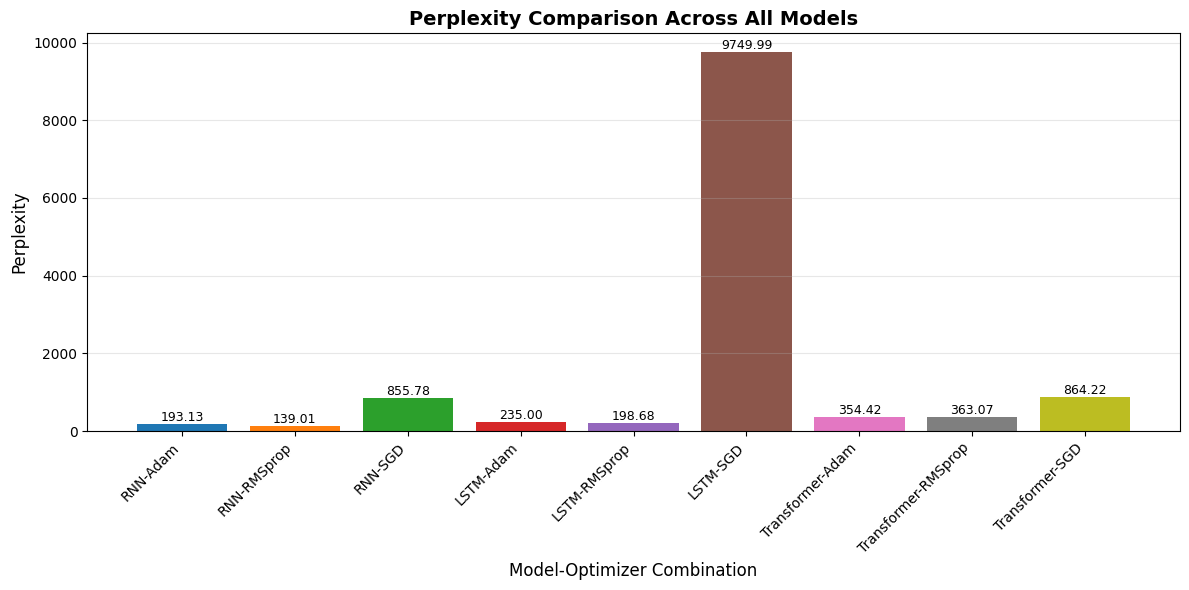

In [5]:
# Create perplexity comparison plot
fig, ax = plt.subplots(figsize=(12, 6))

x_pos = np.arange(len(df))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22']

bars = ax.bar(x_pos, df['perplexity'], color=colors[:len(df)])

# Add labels
ax.set_xlabel('Model-Optimizer Combination', fontsize=12)
ax.set_ylabel('Perplexity', fontsize=12)
ax.set_title('Perplexity Comparison Across All Models', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels([f"{row['model']}-{row['optimizer']}" for _, row in df.iterrows()],
                    rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, df['perplexity'])):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


## Training Time Comparison Plot


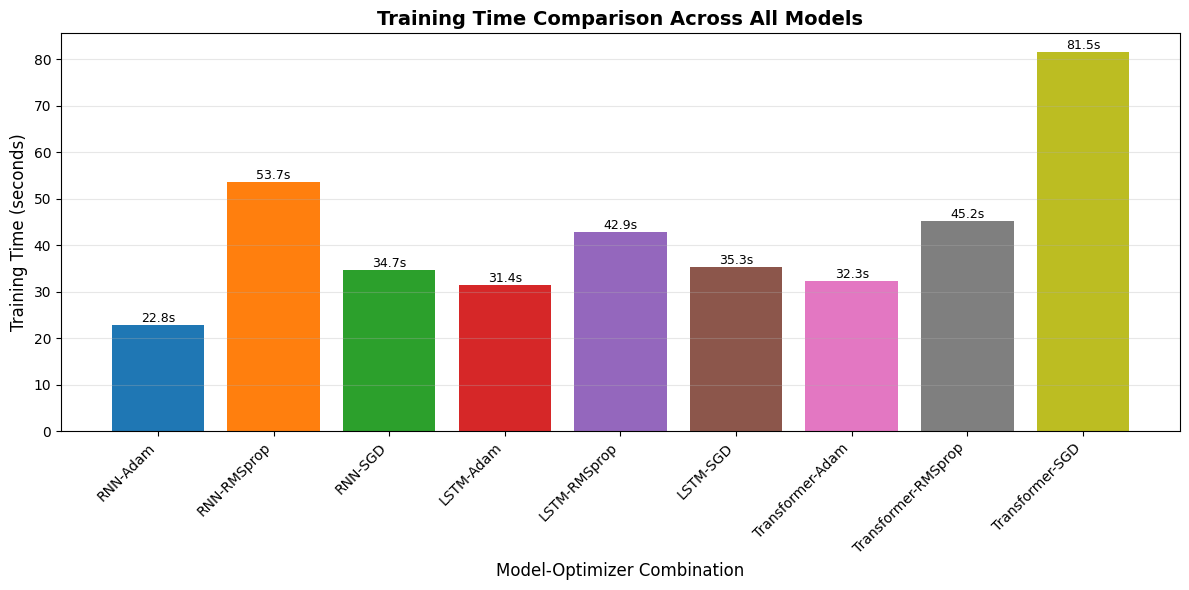

In [6]:
# Create training time comparison plot
fig, ax = plt.subplots(figsize=(12, 6))

x_pos = np.arange(len(df))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22']

bars = ax.bar(x_pos, df['training_time'], color=colors[:len(df)])

# Add labels
ax.set_xlabel('Model-Optimizer Combination', fontsize=12)
ax.set_ylabel('Training Time (seconds)', fontsize=12)
ax.set_title('Training Time Comparison Across All Models', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels([f"{row['model']}-{row['optimizer']}" for _, row in df.iterrows()],
                    rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, df['training_time'])):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}s', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


## Loss Comparison Tables


In [7]:
# Display loss comparison tables
print("=" * 80)
print("LOSS COMPARISON TABLE")
print("=" * 80)
print("\nTrain Loss:")
print(df[['model', 'optimizer', 'train_loss']].to_string(index=False))
print("\nValidation Loss:")
print(df[['model', 'optimizer', 'val_loss']].to_string(index=False))
print("\nTest Loss:")
print(df[['model', 'optimizer', 'test_loss']].to_string(index=False))
print("\nPerplexity:")
print(df[['model', 'optimizer', 'perplexity']].to_string(index=False))
print("=" * 80)


LOSS COMPARISON TABLE

Train Loss:
      model optimizer  train_loss
        RNN      Adam    3.616657
        RNN   RMSprop    3.318506
        RNN       SGD    6.767591
       LSTM      Adam    3.933584
       LSTM   RMSprop    4.878351
       LSTM       SGD    9.186385
Transformer      Adam    5.684427
Transformer   RMSprop    5.813680
Transformer       SGD    6.783206

Validation Loss:
      model optimizer  val_loss
        RNN      Adam  5.308016
        RNN   RMSprop  4.965223
        RNN       SGD  6.800785
       LSTM      Adam  5.549473
       LSTM   RMSprop  5.369602
       LSTM       SGD  9.188443
Transformer      Adam  5.920477
Transformer   RMSprop  5.941723
Transformer       SGD  6.817018

Test Loss:
      model optimizer  test_loss
        RNN      Adam   5.263339
        RNN   RMSprop   4.934547
        RNN       SGD   6.752016
       LSTM      Adam   5.459606
       LSTM   RMSprop   5.291675
       LSTM       SGD   9.185021
Transformer      Adam   5.870478
Transformer

## Hyperparameter Experiments

We will experiment with different learning rates to see their impact on model performance.


In [8]:
# Load processed data
X_train = np.load('../data/processed/X_train.npy')
y_train = np.load('../data/processed/y_train.npy')
X_val = np.load('../data/processed/X_val.npy')
y_val = np.load('../data/processed/y_val.npy')
X_test = np.load('../data/processed/X_test.npy')
y_test = np.load('../data/processed/y_test.npy')

with open('../data/processed/tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)

with open('../data/processed/metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)

vocab_size = metadata['vocab_size']
sequence_length = metadata['sequence_length']

print("Data loaded for hyperparameter experiments!")


Data loaded for hyperparameter experiments!


In [9]:
# Build LSTM model function (using LSTM as example for hyperparameter experiments)
def build_lstm_model(vocab_size, sequence_length, embedding_dim=128, lstm_units=256, num_layers=1, dropout_rate=0.0):
    """Build an LSTM model for next-word prediction"""
    model = Sequential()
    model.add(Embedding(vocab_size, embedding_dim, input_length=sequence_length))

    # Add LSTM layers
    for i in range(num_layers):
        return_sequences = (i < num_layers - 1)  # Only last layer doesn't return sequences
        if i == 0:
            model.add(LSTM(lstm_units, return_sequences=return_sequences, dropout=dropout_rate))
        else:
            model.add(LSTM(lstm_units, return_sequences=return_sequences, dropout=dropout_rate))

    model.add(Dense(vocab_size, activation='softmax'))
    return model

# Get baseline for comparison
baseline = df[(df['model'] == 'LSTM') & (df['optimizer'] == 'Adam')].iloc[0]
baseline_perplexity = baseline['perplexity']

print("=" * 80)
print("HYPERPARAMETER EXPERIMENTS")
print("=" * 80)
print(f"Baseline (LSTM + Adam): Perplexity = {baseline_perplexity:.2f}")
print("=" * 80)

all_experiment_results = []

# Experiment 1: Learning Rate
print("\n" + "=" * 80)
print("EXPERIMENT 1: Learning Rate")
print("=" * 80)
learning_rates = [0.0001, 0.001, 0.01, 0.1]  # As per project requirements

for lr in learning_rates:
    print(f"\nTraining LSTM with learning rate: {lr}")
    print("-" * 60)

    model = build_lstm_model(vocab_size, sequence_length)
    optimizer = Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    start_time = time.time()
    history = model.fit(X_train, y_train, batch_size=128, epochs=25,
                       validation_data=(X_val, y_val), callbacks=[early_stopping], verbose=0)
    training_time = time.time() - start_time

    train_loss, _ = model.evaluate(X_train, y_train, verbose=0)
    val_loss, _ = model.evaluate(X_val, y_val, verbose=0)
    test_loss, _ = model.evaluate(X_test, y_test, verbose=0)
    perplexity = np.exp(test_loss)

    all_experiment_results.append({
        'experiment': 'Learning Rate',
        'parameter': 'learning_rate',
        'value': lr,
        'perplexity': perplexity,
        'test_loss': test_loss,
        'training_time': training_time,
        'change_vs_baseline': perplexity - baseline_perplexity
    })

    print(f"  Perplexity: {perplexity:.2f} ({'+' if perplexity > baseline_perplexity else ''}{perplexity - baseline_perplexity:.2f} vs baseline)")

# Experiment 2: Batch Size
print("\n" + "=" * 80)
print("EXPERIMENT 2: Batch Size")
print("=" * 80)
batch_sizes = [32, 64, 128, 256]  # As per project requirements

for bs in batch_sizes:
    print(f"\nTraining LSTM with batch size: {bs}")
    print("-" * 60)

    model = build_lstm_model(vocab_size, sequence_length)
    optimizer = Adam(learning_rate=0.001)  # Baseline LR
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    start_time = time.time()
    history = model.fit(X_train, y_train, batch_size=bs, epochs=25,
                       validation_data=(X_val, y_val), callbacks=[early_stopping], verbose=0)
    training_time = time.time() - start_time

    train_loss, _ = model.evaluate(X_train, y_train, verbose=0)
    val_loss, _ = model.evaluate(X_val, y_val, verbose=0)
    test_loss, _ = model.evaluate(X_test, y_test, verbose=0)
    perplexity = np.exp(test_loss)

    all_experiment_results.append({
        'experiment': 'Batch Size',
        'parameter': 'batch_size',
        'value': bs,
        'perplexity': perplexity,
        'test_loss': test_loss,
        'training_time': training_time,
        'change_vs_baseline': perplexity - baseline_perplexity
    })

    print(f"  Perplexity: {perplexity:.2f} ({'+' if perplexity > baseline_perplexity else ''}{perplexity - baseline_perplexity:.2f} vs baseline)")

# Experiment 3: Number of Layers
print("\n" + "=" * 80)
print("EXPERIMENT 3: Number of Layers")
print("=" * 80)
num_layers_list = [1, 2, 3]  # As per project requirements

for num_layers in num_layers_list:
    print(f"\nTraining LSTM with {num_layers} layer(s)")
    print("-" * 60)

    model = build_lstm_model(vocab_size, sequence_length, num_layers=num_layers)
    optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    start_time = time.time()
    history = model.fit(X_train, y_train, batch_size=128, epochs=25,
                       validation_data=(X_val, y_val), callbacks=[early_stopping], verbose=0)
    training_time = time.time() - start_time

    train_loss, _ = model.evaluate(X_train, y_train, verbose=0)
    val_loss, _ = model.evaluate(X_val, y_val, verbose=0)
    test_loss, _ = model.evaluate(X_test, y_test, verbose=0)
    perplexity = np.exp(test_loss)

    all_experiment_results.append({
        'experiment': 'Number of Layers',
        'parameter': 'num_layers',
        'value': num_layers,
        'perplexity': perplexity,
        'test_loss': test_loss,
        'training_time': training_time,
        'change_vs_baseline': perplexity - baseline_perplexity
    })

    print(f"  Perplexity: {perplexity:.2f} ({'+' if perplexity > baseline_perplexity else ''}{perplexity - baseline_perplexity:.2f} vs baseline)")

# Experiment 4: Dropout Rate
print("\n" + "=" * 80)
print("EXPERIMENT 4: Dropout Rate")
print("=" * 80)
dropout_rates = [0.1, 0.2, 0.3, 0.5]  # As per project requirements

for dropout_rate in dropout_rates:
    print(f"\nTraining LSTM with dropout rate: {dropout_rate}")
    print("-" * 60)

    model = build_lstm_model(vocab_size, sequence_length, dropout_rate=dropout_rate)
    optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    start_time = time.time()
    history = model.fit(X_train, y_train, batch_size=128, epochs=25,
                       validation_data=(X_val, y_val), callbacks=[early_stopping], verbose=0)
    training_time = time.time() - start_time

    train_loss, _ = model.evaluate(X_train, y_train, verbose=0)
    val_loss, _ = model.evaluate(X_val, y_val, verbose=0)
    test_loss, _ = model.evaluate(X_test, y_test, verbose=0)
    perplexity = np.exp(test_loss)

    all_experiment_results.append({
        'experiment': 'Dropout Rate',
        'parameter': 'dropout_rate',
        'value': dropout_rate,
        'perplexity': perplexity,
        'test_loss': test_loss,
        'training_time': training_time,
        'change_vs_baseline': perplexity - baseline_perplexity
    })

    print(f"  Perplexity: {perplexity:.2f} ({'+' if perplexity > baseline_perplexity else ''}{perplexity - baseline_perplexity:.2f} vs baseline)")

# Create summary DataFrame
exp_df = pd.DataFrame(all_experiment_results)

print("\n" + "=" * 80)
print("HYPERPARAMETER EXPERIMENT RESULTS SUMMARY")
print("=" * 80)
print(exp_df[['experiment', 'parameter', 'value', 'perplexity', 'change_vs_baseline', 'training_time']].to_string(index=False))
print("=" * 80)


HYPERPARAMETER EXPERIMENTS
Baseline (LSTM + Adam): Perplexity = 235.00

EXPERIMENT 1: Learning Rate

Training LSTM with learning rate: 0.0001
------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


  Perplexity: 349.06 (+114.05 vs baseline)

Training LSTM with learning rate: 0.001
------------------------------------------------------------
  Perplexity: 230.84 (-4.16 vs baseline)

Training LSTM with learning rate: 0.01
------------------------------------------------------------
  Perplexity: 182.87 (-52.13 vs baseline)

Training LSTM with learning rate: 0.1
------------------------------------------------------------
  Perplexity: 3059.49 (+2824.48 vs baseline)

EXPERIMENT 2: Batch Size

Training LSTM with batch size: 32
------------------------------------------------------------
  Perplexity: 268.75 (+33.75 vs baseline)

Training LSTM with batch size: 64
------------------------------------------------------------
  Perplexity: 263.88 (+28.88 vs baseline)

Training LSTM with batch size: 128
------------------------------------------------------------
  Perplexity: 244.48 (+9.47 vs baseline)

Training LSTM with batch size: 256
--------------------------------------------------

BEFORE vs AFTER HYPERPARAMETER EXPERIMENTS

Baseline (LSTM + Adam, LR=0.001, Batch=128):
  Test Loss: 5.4596
  Perplexity: 235.00
  Training Time: 31.37s

Learning Rate Experiments:
------------------------------------------------------------
  learning_rate = 0.0001:
    Perplexity: 349.06 (+114.05 vs baseline)
    Test Loss: 5.8552
    Training Time: 479.20s
  learning_rate = 0.001:
    Perplexity: 230.84 (-4.16 vs baseline)
    Test Loss: 5.4417
    Training Time: 987.66s
  learning_rate = 0.01:
    Perplexity: 182.87 (-52.13 vs baseline)
    Test Loss: 5.2088
    Training Time: 398.68s
  learning_rate = 0.1:
    Perplexity: 3059.49 (+2824.48 vs baseline)
    Test Loss: 8.0260
    Training Time: 317.95s

Batch Size Experiments:
------------------------------------------------------------
  batch_size = 32.0:
    Perplexity: 268.75 (+33.75 vs baseline)
    Test Loss: 5.5938
    Training Time: 915.42s
  batch_size = 64.0:
    Perplexity: 263.88 (+28.88 vs baseline)
    Test Loss: 5.57

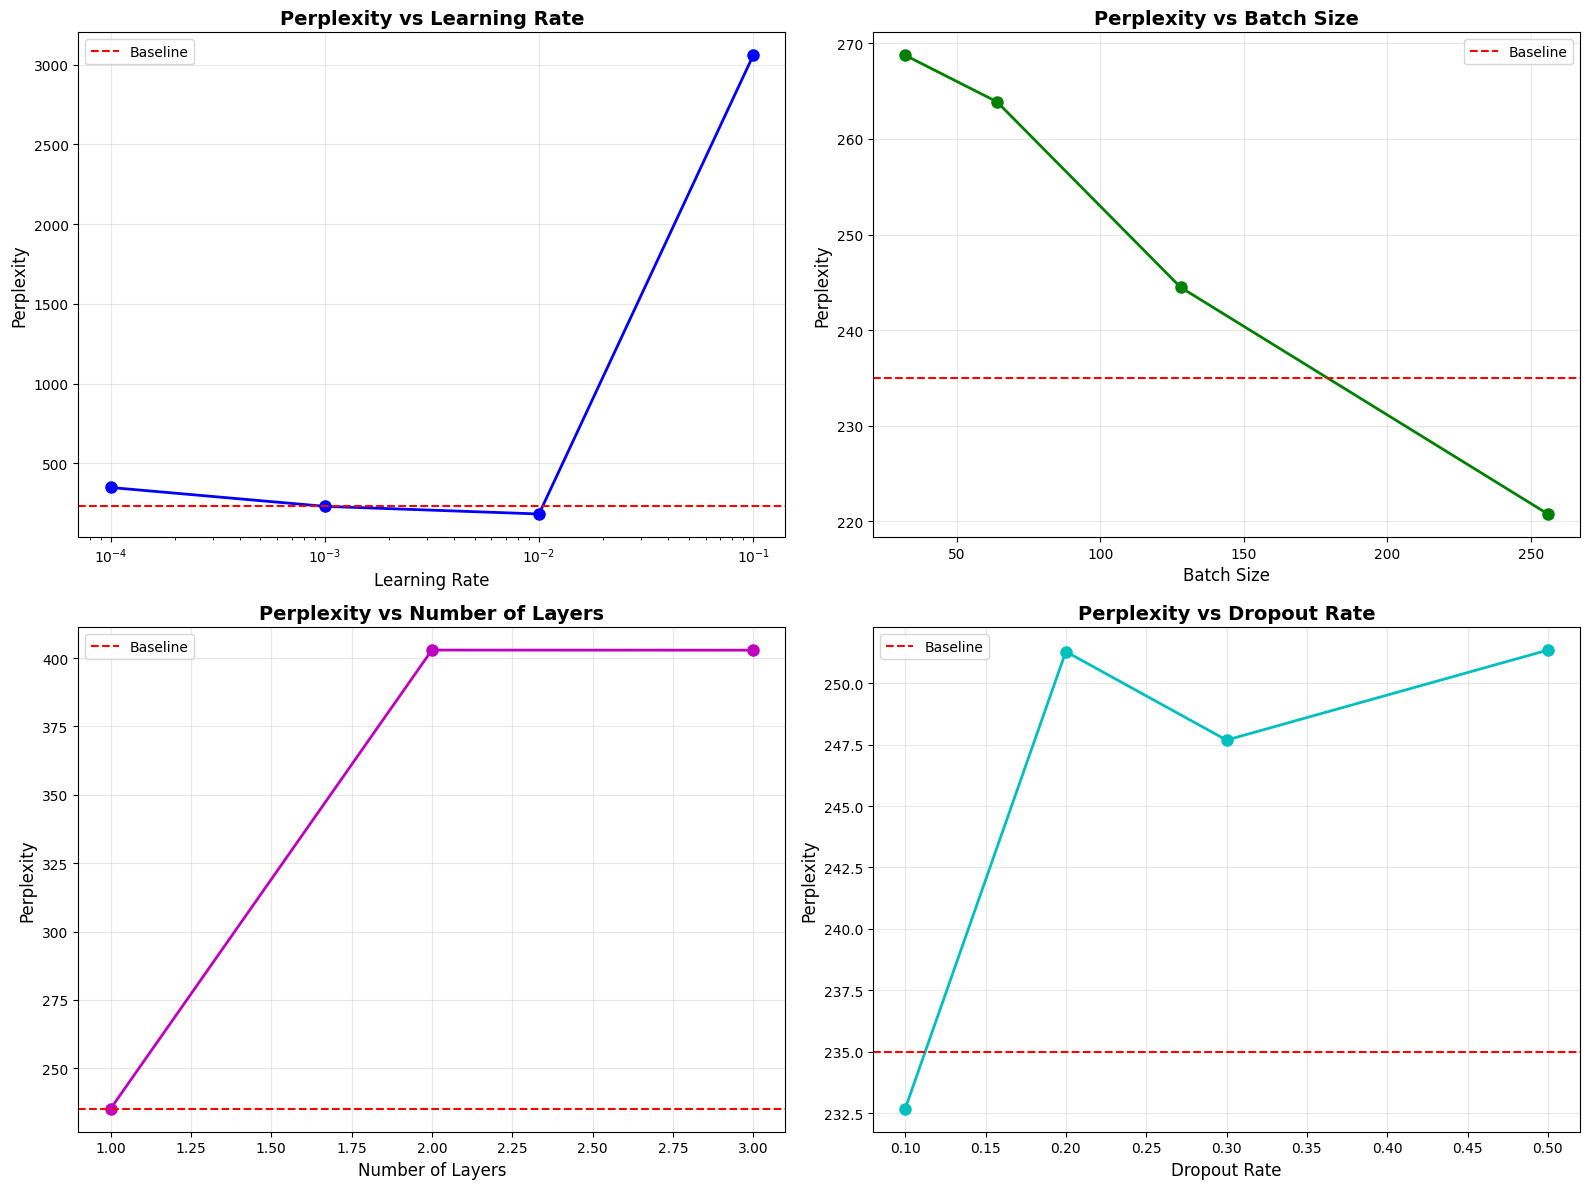


BEST HYPERPARAMETER CONFIGURATION
Experiment: Learning Rate
Parameter: learning_rate = 0.01
Perplexity: 182.87
Improvement vs Baseline: -52.13


In [10]:
# Compare baseline with all hyperparameter experiments
baseline = df[(df['model'] == 'LSTM') & (df['optimizer'] == 'Adam')].iloc[0]

print("=" * 80)
print("BEFORE vs AFTER HYPERPARAMETER EXPERIMENTS")
print("=" * 80)
print(f"\nBaseline (LSTM + Adam, LR=0.001, Batch=128):")
print(f"  Test Loss: {baseline['test_loss']:.4f}")
print(f"  Perplexity: {baseline['perplexity']:.2f}")
print(f"  Training Time: {baseline['training_time']:.2f}s")

# Display results by experiment type
for exp_type in exp_df['experiment'].unique():
    exp_subset = exp_df[exp_df['experiment'] == exp_type]
    print(f"\n{exp_type} Experiments:")
    print("-" * 60)
    for _, row in exp_subset.iterrows():
        param_name = row['parameter']
        param_value = row['value']
        change = row['change_vs_baseline']
        print(f"  {param_name} = {param_value}:")
        print(f"    Perplexity: {row['perplexity']:.2f} ({'+' if change > 0 else ''}{change:.2f} vs baseline)")
        print(f"    Test Loss: {row['test_loss']:.4f}")
        print(f"    Training Time: {row['training_time']:.2f}s")

# Plot comparisons
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Learning Rate experiments
lr_df = exp_df[exp_df['experiment'] == 'Learning Rate']
ax1 = axes[0, 0]
ax1.plot(lr_df['value'], lr_df['perplexity'], 'bo-', linewidth=2, markersize=8)
ax1.axhline(y=baseline['perplexity'], color='r', linestyle='--', label='Baseline')
ax1.set_xlabel('Learning Rate', fontsize=12)
ax1.set_ylabel('Perplexity', fontsize=12)
ax1.set_title('Perplexity vs Learning Rate', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xscale('log')

# Batch Size experiments
batch_df = exp_df[exp_df['experiment'] == 'Batch Size']
ax2 = axes[0, 1]
ax2.plot(batch_df['value'], batch_df['perplexity'], 'go-', linewidth=2, markersize=8)
ax2.axhline(y=baseline['perplexity'], color='r', linestyle='--', label='Baseline')
ax2.set_xlabel('Batch Size', fontsize=12)
ax2.set_ylabel('Perplexity', fontsize=12)
ax2.set_title('Perplexity vs Batch Size', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Number of Layers experiments
layers_df = exp_df[exp_df['experiment'] == 'Number of Layers']
ax3 = axes[1, 0]
ax3.plot(layers_df['value'], layers_df['perplexity'], 'mo-', linewidth=2, markersize=8)
ax3.axhline(y=baseline['perplexity'], color='r', linestyle='--', label='Baseline')
ax3.set_xlabel('Number of Layers', fontsize=12)
ax3.set_ylabel('Perplexity', fontsize=12)
ax3.set_title('Perplexity vs Number of Layers', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Dropout Rate experiments
dropout_df = exp_df[exp_df['experiment'] == 'Dropout Rate']
ax4 = axes[1, 1]
ax4.plot(dropout_df['value'], dropout_df['perplexity'], 'co-', linewidth=2, markersize=8)
ax4.axhline(y=baseline['perplexity'], color='r', linestyle='--', label='Baseline')
ax4.set_xlabel('Dropout Rate', fontsize=12)
ax4.set_ylabel('Perplexity', fontsize=12)
ax4.set_title('Perplexity vs Dropout Rate', fontsize=14, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find best experiment
best_exp = exp_df.loc[exp_df['perplexity'].idxmin()]
print("\n" + "=" * 80)
print("BEST HYPERPARAMETER CONFIGURATION")
print("=" * 80)
print(f"Experiment: {best_exp['experiment']}")
print(f"Parameter: {best_exp['parameter']} = {best_exp['value']}")
print(f"Perplexity: {best_exp['perplexity']:.2f}")
print(f"Improvement vs Baseline: {best_exp['change_vs_baseline']:.2f}")
print("=" * 80)


In [11]:
# Load generated poems for evaluation
import glob

generated_files = glob.glob('../results/generated_poems/*.txt')
print(f"Found {len(generated_files)} generated poem files")

# Create qualitative evaluation framework
# Note: This is a template - actual ratings should be filled manually
qualitative_evaluation = {
    'RNN_Adam': {'Fluency': 0, 'Coherence': 0, 'Creativity': 0, 'Poetic_Quality': 0},
    'RNN_RMSprop': {'Fluency': 0, 'Coherence': 0, 'Creativity': 0, 'Poetic_Quality': 0},
    'RNN_SGD': {'Fluency': 0, 'Coherence': 0, 'Creativity': 0, 'Poetic_Quality': 0},
    'LSTM_Adam': {'Fluency': 0, 'Coherence': 0, 'Creativity': 0, 'Poetic_Quality': 0},
    'LSTM_RMSprop': {'Fluency': 0, 'Coherence': 0, 'Creativity': 0, 'Poetic_Quality': 0},
    'LSTM_SGD': {'Fluency': 0, 'Coherence': 0, 'Creativity': 0, 'Poetic_Quality': 0},
    'Transformer_Adam': {'Fluency': 0, 'Coherence': 0, 'Creativity': 0, 'Poetic_Quality': 0},
    'Transformer_RMSprop': {'Fluency': 0, 'Coherence': 0, 'Creativity': 0, 'Poetic_Quality': 0},
    'Transformer_SGD': {'Fluency': 0, 'Coherence': 0, 'Creativity': 0, 'Poetic_Quality': 0},
}

# Display evaluation template
print("\n" + "=" * 80)
print("QUALITATIVE EVALUATION TEMPLATE")
print("=" * 80)
print("\nRating Scale: 1 (Poor) to 5 (Excellent)")
print("\nEvaluation Criteria:")
print("  - Fluency: How natural and grammatically correct is the text?")
print("  - Coherence: How well do the lines connect and make sense together?")
print("  - Creativity: How original and creative are the generated verses?")
print("  - Poetic Quality: How well does it capture the essence of Urdu poetry?")

# Create DataFrame for qualitative evaluation
qual_df = pd.DataFrame(qualitative_evaluation).T
qual_df.columns = ['Fluency', 'Coherence', 'Creativity', 'Poetic Quality']

print("\n" + "=" * 80)
print("QUALITATIVE EVALUATION TABLE (Template - Fill manually)")
print("=" * 80)
print(qual_df.to_string())
print("\nNote: Please manually evaluate the generated poems and update the ratings above.")
print("=" * 80)


Found 6 generated poem files

QUALITATIVE EVALUATION TEMPLATE

Rating Scale: 1 (Poor) to 5 (Excellent)

Evaluation Criteria:
  - Fluency: How natural and grammatically correct is the text?
  - Coherence: How well do the lines connect and make sense together?
  - Creativity: How original and creative are the generated verses?
  - Poetic Quality: How well does it capture the essence of Urdu poetry?

QUALITATIVE EVALUATION TABLE (Template - Fill manually)
                     Fluency  Coherence  Creativity  Poetic Quality
RNN_Adam                   0          0           0               0
RNN_RMSprop                0          0           0               0
RNN_SGD                    0          0           0               0
LSTM_Adam                  0          0           0               0
LSTM_RMSprop               0          0           0               0
LSTM_SGD                   0          0           0               0
Transformer_Adam           0          0           0               0

## Best Performing Model Summary


In [12]:
# Find best model based on perplexity (lower is better)
best_model_idx = df['perplexity'].idxmin()
best_model = df.loc[best_model_idx]

print("=" * 80)
print("BEST PERFORMING MODEL SUMMARY")
print("=" * 80)
print(f"\nModel: {best_model['model']}")
print(f"Optimizer: {best_model['optimizer']}")
print(f"\nPerformance Metrics:")
print(f"  Train Loss: {best_model['train_loss']:.4f}")
print(f"  Validation Loss: {best_model['val_loss']:.4f}")
print(f"  Test Loss: {best_model['test_loss']:.4f}")
print(f"  Perplexity: {best_model['perplexity']:.2f}")
print(f"  Training Time: {best_model['training_time']:.2f} seconds")
print("=" * 80)

# Also show top 3 models
print("\n" + "=" * 80)
print("TOP 3 MODELS BY PERPLEXITY (Lower is Better)")
print("=" * 80)
top_3 = df.nsmallest(3, 'perplexity')[['model', 'optimizer', 'perplexity', 'test_loss', 'training_time']]
print(top_3.to_string(index=False))
print("=" * 80)


BEST PERFORMING MODEL SUMMARY

Model: RNN
Optimizer: RMSprop

Performance Metrics:
  Train Loss: 3.3185
  Validation Loss: 4.9652
  Test Loss: 4.9345
  Perplexity: 139.01
  Training Time: 53.68 seconds

TOP 3 MODELS BY PERPLEXITY (Lower is Better)
model optimizer  perplexity  test_loss  training_time
  RNN   RMSprop  139.010216   4.934547      53.675207
  RNN      Adam  193.125269   5.263339      22.809120
 LSTM   RMSprop  198.675852   5.291675      42.872937


## Best Qualitative Samples Summary


In [13]:
# Display sample generated poems from best model
best_model_file = f"../results/generated_poems/{best_model['model'].lower()}_{best_model['optimizer'].lower()}.txt"

print("=" * 80)
print("BEST QUALITATIVE SAMPLES FROM BEST MODEL")
print("=" * 80)
print(f"\nModel: {best_model['model']} - {best_model['optimizer']}")
print(f"File: {best_model_file}")

try:
    with open(best_model_file, 'r', encoding='utf-8') as f:
        content = f.read()
        print("\n" + content[:2000])  # Show first 2000 characters
        if len(content) > 2000:
            print("\n... (truncated)")
except FileNotFoundError:
    print(f"\nFile not found: {best_model_file}")
    print("Please run the text generation notebook first.")

print("\n" + "=" * 80)
print("Note: For complete qualitative evaluation, please:")
print("  1. Review all generated poems in results/generated_poems/")
print("  2. Rate each model on Fluency, Coherence, Creativity, and Poetic Quality")
print("  3. Update the qualitative evaluation table above")
print("=" * 80)


BEST QUALITATIVE SAMPLES FROM BEST MODEL

Model: RNN - RMSprop
File: ../results/generated_poems/rnn_rmsprop.txt

Generated Poetry - RNN_RMSprop

Seed Word: محبت

Temperature: 0.7
------------------------------------------------------------
Sample 1:
محبت پکارنے ابھرتے لگا پہنچا کیا ہے مجھے مجھے ہوں میں
مجھے ہوں میں ہوں میں لیکن کیا کیا کیا ہوا ہے مجھے بھی
ہے مجھے بھی رنگ آوے ہے ساقی کا پھری آخر ہے ساقی میرا
ہے ساقی میرا چاند ہے ہے موجود پر بھی نہیں دیا کیا غرض
دیا کیا غرض ہوتا ہے لیکن کہئے بھی نہیں رہا کیا ہو جائے

Sample 2:
محبت پر اجلی چمکیں دریغا نہیں ہوتیں کوئی بھی نہیں ہے
بھی نہیں ہے آئنہ مرا کا دوست کچھ ہے مجھے آوے ہے غالبؔ
آوے ہے غالبؔ میرا سخن کا تھے ہم کو بھی نہیں جاتا ہوں
نہیں جاتا ہوں میں اسدؔ رکھا ہے کہیں کوئی منتظر ہیں فرازؔ دوست
ہیں فرازؔ دوست تنہائی سے کہیں آیا کیا ہوگا مصحفیؔ کی طرح کیا

Sample 3:
محبت آیا ہے پہنچا مقبول جاتے ہیں ہم لوگ بھی ہیں
لوگ بھی ہیں تیار غالبؔ کوئی نہیں ہے عشق میں آنکھیں خبر کی
آنکھیں خبر کی طرح کیا ہے کہیں میں تھا میں دیکھو دیا کیا
دیکھو دیا کیا